# C1.1 — The Forward Euler Numerical Method

<hr style="height:2px;border-width:0;color:gray;background-color:gray">

## C1.1.1 — Motivation

Numerical methods allow us to approximate solutions to differential equations when exact analytic solutions are difficult or impossible to obtain. 

In physics, engineering, biology, and economics, many systems evolve according to differential equations:

- motion of planets,
- radioactive decay,
- electrical circuits,
- population dynamics,
- fluid flow,
- quantum systems.

Often, the equations cannot be solved neatly by hand. Instead, we approximate the solution step-by-step using computational methods.

The **Forward Euler Method** is the simplest numerical integration technique for ordinary differential equations (ODEs). It forms the conceptual foundation for more advanced methods such as:

- Runge–Kutta methods,
- Verlet integration,
- Predictor–Corrector schemes,
- Finite difference methods.

The key idea is simple:

> If we know the slope of a function at the current point, we can estimate where the function will be a short time later.

This transforms a continuous differential equation into a sequence of discrete computational steps.
<hr style="height:2px;border-width:0;color:gray;background-color:gray">

## C1.1.2 — Ordinary Differential Equations

A first-order ordinary differential equation can be written as

$$
\frac{dy}{dt} = f(t,y)
$$

where:

- $y(t)$ is the unknown function,
- $t$ is the independent variable,
- $f(t,y)$ gives the rate of change of $y$.

To uniquely determine the solution, we also require an initial condition:

$$
y(t_0)=y_0
$$

The problem is therefore called an **initial value problem (IVP)**.
<hr style="height:2px;border-width:0;color:gray;background-color:gray">

## C1.1.3 — Geometric Idea Behind Euler's Method

Let us consider the graphical setup below. Assume that we know a solution point

$$
[t_0,y(t_0)]
$$

of a function $y(t)$, and we wish to estimate the solution at a nearby point

$$
[t,y(t)].
$$

In the Figure below, the blue curve represents the true solution $y(t)$. The red line is the tangent line at the point $[t_0,y(t_0)]$, which provides the best local linear approximation to the solution near that point.

The tangent line is

<div style="background-color:#e8f5e9; border-left:6px solid #006633; padding:14px; border-radius:4px;">

$$
L(t)=y(t_0)+\left.\frac{dy}{dt}\right|_{t=t_0}(t-t_0)
\tag{1}
$$

</div>

If the differential equation is

$$
\frac{dy}{dt}=f(t,y),
$$

then the slope at the point $(t_0,y(t_0))$ is

$$
f(t_0,y(t_0)).
$$

Therefore, Equation (1) becomes

$$
L(t)=y(t_0)+f(t_0,y(t_0))(t-t_0).
$$

For a small step size

$$
h=t-t_0,
$$

we obtain

$$
L(t_0+h)=y(t_0)+h f(t_0,y(t_0)).
$$

The Forward Euler method uses precisely this tangent-line approximation to estimate the next value of the solution:

$$
y_{n+1}=y_n+h f(t_n,y_n).
$$

Thus, Euler's method advances the solution by moving along the tangent direction determined by the differential equation.

<div style="background-color:#ffe6e6; border-left:6px solid #cc0000; padding:14px; border-radius:4px;">

<strong>Danger:</strong><br>

The tangent line only approximates the solution locally. As we move farther away from the known point, the discrepancy between the tangent line and the true solution generally increases. This accumulated discrepancy is the numerical error of the method.

</div>

---

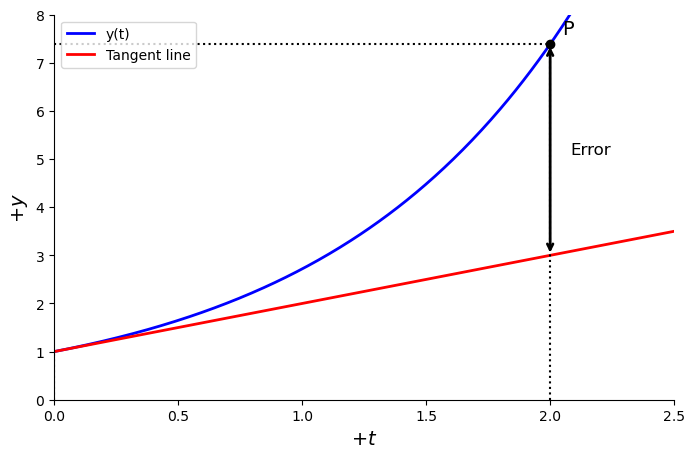

In [5]:
%reset -f

import numpy as np
import matplotlib.pyplot as plt

# Define the exact solution y(t)
def y(t):
    return np.exp(t)

# Initial point
t0 = 0
y0 = y(t0)

# Choose nearby point
t = np.linspace(0, 2.5, 400)

# Tangent line (linearization)
L = y0 + y0 * (t - t0)

# Exact curve
y_exact = y(t)

# Point P
tP = 2.0
yP = y(tP)

# Tangent estimate at P
LP = y0 + y0 * (tP - t0)

# Create figure
plt.figure(figsize=(8,5))

# Exact solution
plt.plot(t, y_exact, color='blue', linewidth=2, label='y(t)')

# Tangent line
plt.plot(t, L, color='red', linewidth=2, label='Tangent line')

# Point P
plt.plot(tP, yP, 'ko')
plt.text(tP + 0.05, yP + 0.2, 'P', fontsize=14)

# Vertical dotted lines
plt.vlines([t0, tP], ymin=0, ymax=[y0, yP],
           colors='black', linestyles='dotted')

# Horizontal dotted lines
plt.hlines([y0, yP], xmin=0, xmax=[t0, tP],
           colors='black', linestyles='dotted')

# the error
plt.annotate(
    '',
    xy=(tP, yP),
    xytext=(tP, LP),
    arrowprops=dict(
        arrowstyle='<->',
        color='black',
        lw=2
    )
)

# Error label
plt.text(
    tP + 0.08,
    (yP + LP)/2,
    'Error',
    fontsize=12,
    verticalalignment='center'
)

# Labels
plt.xlabel(r'$+t$', fontsize=14)
plt.ylabel(r'$+y$', fontsize=14)

# Axis limits
plt.xlim(0, 2.5)
plt.ylim(0, 8)

# Remove top/right spines
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

# Grid
plt.grid(False)

plt.legend()
plt.show()

<hr style="height:2px;border-width:0;color:gray;background-color:gray">

## C1.1.4 — The Forward Euler Formula

<div style="background-color:#e6f0ff; border-left:6px solid #003366; padding:12px; border-radius:4px;">

<strong>Forward Euler Method</strong>

For the differential equation

$$
\frac{dy}{dt}=f(t,y)
$$

with initial condition

$$
y(t_0)=y_0,
$$

the Forward Euler numerical approximation is

$$
y_{n+1}=y_n+h f(t_n,y_n)
$$

where:

- $h$ is the step size,
- $t_{n+1}=t_n+h$,
- $y_n$ approximates the exact solution at time $t_n$.

</div>

The method is called **forward** because it advances the solution forward in time using information from the current point only.
<hr style="height:2px;border-width:0;color:gray;background-color:gray">

## C1.1.5 — Derivation from Taylor Expansion

We derive Euler's method from the Taylor expansion of $y(t+h)$ around $t$:

$$
y(t+h)=y(t)+h y'(t)+\frac{h^2}{2}y''(t)+\cdots
$$

Using the differential equation:

$$
y'(t)=f(t,y)
$$

gives

$$
y(t+h)=y(t)+h f(t,y)+\mathcal{O}(h^2)
$$

Neglecting higher-order terms yields

$$
y(t+h)\approx y(t)+h f(t,y)
$$

which is precisely the Forward Euler formula.

<div style="background-color:#fff8e1; border-left:6px solid #ffcc00; padding:14px; border-radius:4px;">

<strong>Curiosity:</strong><br>

The Forward Euler method is classified as a <strong>first-order finite difference method</strong>.

- It is called a <strong>finite difference</strong> method because derivatives are approximated using finite step sizes:

$$
\frac{dy}{dt}\approx \frac{y_{n+1}-y_n}{h}.
$$

- Euler's method is a <strong>first-order method</strong> because the truncation error scales as

$$
\mathcal{O}(h^2)
$$

locally at each step, while the accumulated global error scales as

$$
\mathcal{O}(h).
$$

This means that halving the step size approximately halves the overall numerical error.

</div>

<hr style="height:2px;border-width:0;color:gray;background-color:gray">

## C1.1.6 — Worked Example

<div style="background-color:#e0f7fa; border-left:6px solid #006a80; padding:14px; border-radius:4px;">

<h3 style="margin-top:0;">Example — Exponential Growth</h3>

Solve numerically using Forward Euler:

$$
\frac{dy}{dt}=y
$$

with

$$
y(0)=1
$$

using step size

$$
h=0.1
$$

for the first three steps.

---

The Euler update formula is

$$
y_{n+1}=y_n+h y_n
$$

which simplifies to

$$
y_{n+1}=(1+h)y_n.
$$

Since $h=0.1$:

$$
y_{n+1}=1.1y_n
$$

Initial condition:

$$
y_0=1.
$$

<strong>Step 1</strong>

$$
y_1=1.1(1)=1.1
$$

<strong>Step 2</strong>

$$
y_2=1.1(1.1)=1.21
$$

<strong>Step 3</strong>

$$
y_3=1.1(1.21)=1.331
$$

Thus the approximate values are

| $n$ | $t_n$ | $y_n$ |
|---|---|---|
| 0 | 0.0 | 1.000 |
| 1 | 0.1 | 1.100 |
| 2 | 0.2 | 1.210 |
| 3 | 0.3 | 1.331 |

Thus the Euler approximation at

$$
t=0.3
$$

is

$$
y_{\text{Euler}}=1.331.
$$

The exact analytic solution is

$$
y=e^t.
$$

Therefore,

$$
y_{\text{exact}}(0.3)=e^{0.3}\approx1.3499.
$$

The absolute error is

$$
|1.3499-1.331|=0.0189.
$$

The percentage error is

$$
\text{Percentage Error}
=
\frac{|1.3499-1.331|}{1.3499}\times100\%
\approx1.40\%.
$$

<div style="background-color:#fff8e1; border-left:6px solid #ffcc00; padding:14px; border-radius:4px;">

<strong>Curiosity:</strong><br>

Here we are able to compute the exact numerical error because the differential equation has a known analytic solution:

$$
y=e^t.
$$

For many realistic physical systems, an exact analytic solution is not known. In such cases, numerical methods like Euler's method are used precisely because the exact solution cannot be obtained directly.

</div>

<br>

<strong>Below is an example Python script.</strong>

</div>

---

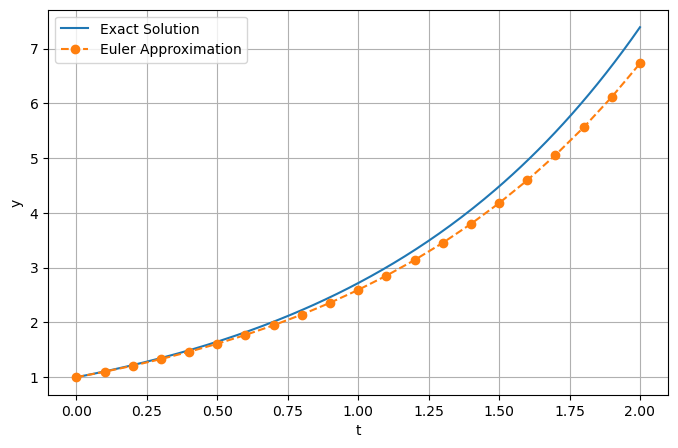

In [6]:
%reset -f

import numpy as np
import matplotlib.pyplot as plt

# Differential equation dy/dt = y
def f(t, y):
    return y

# Parameters
h = 0.1
N = 20

# Arrays
t = np.zeros(N + 1)
y = np.zeros(N + 1)

# Initial condition
t[0] = 0
y[0] = 1

# Euler method
for n in range(N):
    y[n+1] = y[n] + h * f(t[n], y[n])
    t[n+1] = t[n] + h

# Exact solution
t_exact = np.linspace(0, 2, 200)
y_exact = np.exp(t_exact)

# Plot
plt.figure(figsize=(8,5))
plt.plot(t_exact, y_exact, label='Exact Solution')
plt.plot(t, y, 'o--', label='Euler Approximation')
plt.xlabel('t')
plt.ylabel('y')
plt.legend()
plt.grid(True)
plt.show()

<hr style="height:2px;border-width:0;color:gray;background-color:gray">

## C1.1.7 — Stability and Step Size

The Forward Euler method is simple but can become unstable if the step size is too large.

Consider the equation

$$
\frac{dy}{dt}=-\lambda y
$$

with $\lambda>0$.

Euler gives

$$
y_{n+1}=(1-h\lambda)y_n
$$

For stability, repeated multiplication should not grow uncontrollably, requiring

$$
|1-h\lambda|<1
$$

which implies

$$
0<h\lambda<2
$$

Thus the step size must be sufficiently small.

<div style="background-color:#ffe6e6; border-left:6px solid #cc0000; padding:14px; border-radius:4px;">

<strong>Danger:</strong><br>

Choosing a step size that is too large may cause:

<ul>
<li>oscillations,</li>
<li>loss of accuracy,</li>
<li>numerical instability,</li>
<li>completely incorrect solutions.</li>
</ul>

Even stable physical systems can appear unstable numerically if $h$ is poorly chosen.

</div>

<hr style="height:2px;border-width:0;color:gray;background-color:gray">

## C1.1.8 — Algorithmic Procedure

The Forward Euler algorithm follows these steps:

1. Define the differential equation:
   $$
   \frac{dy}{dt}=f(t,y)
   $$

2. Choose:
   - initial condition $(t_0,y_0)$,
   - step size $h$,
   - number of steps.

3. Repeat:
   $$
   y_{n+1}=y_n+h f(t_n,y_n)
   $$

4. Advance time:
   $$
   t_{n+1}=t_n+h
   $$

5. Continue until the desired interval is reached.

<hr style="height:2px;border-width:0;color:gray;background-color:gray">

## C1.1.9 — Box Activity

<div style="background-color:#e8f5e9; border-left:6px solid #006633; padding:14px; border-radius:4px;">

<h3 style="margin-top:0;">Box Activity — Radioactive Decay</h3>

Consider radioactive decay governed by

$$
\frac{dN}{dt}=-0.5N
$$

with initial condition

$$
N(0)=100
$$

Using Forward Euler with step size

$$
h=0.2,
$$

compute:

- $N_1$,
- $N_2$,
- $N_3$,
- the percentage error at $t=0.6$.

<details>
<summary style="background-color:#006633; color:white; padding:8px; border-radius:4px; cursor:pointer;">
Activity solution
</summary>

Euler update rule:

$$
N_{n+1}=N_n+h(-0.5N_n)
$$

Thus

$$
N_{n+1}=(1-0.1)N_n
$$

so

$$
N_{n+1}=0.9N_n.
$$

Initial value:

$$
N_0=100
$$

Then:

$$
N_1=90
$$

$$
N_2=81
$$

$$
N_3=72.9
$$

The exact analytic solution is

$$
N(t)=100e^{-0.5t}.
$$

At

$$
t=0.6,
$$

the exact value is

$$
N_{\text{exact}}(0.6)=100e^{-0.3}\approx74.08.
$$

The Euler approximation is

$$
N_{\text{Euler}}=72.9.
$$

Therefore, the percentage error is

$$
\text{Percentage Error}
=
\frac{|74.08-72.9|}{74.08}\times100\%
\approx1.59\%.
$$

</details>

</div>

<hr style="height:2px;border-width:0;color:gray;background-color:gray">

## C1.1.10 — Forward Euler Backward in Time

So far, we have used the Forward Euler method to advance a solution forward in time:

$$
y_{n+1}=y_n+h f(t_n,y_n),
$$

where $h>0$.

However, there are situations where we may instead wish to move **backward in time**.

This can be done simply by choosing a negative time step:

$$
h<0.
$$

The update equation remains the same:

$$
y_{n+1}=y_n+h f(t_n,y_n),
$$

but now each step moves toward earlier times.

<div style="background-color:#e6f0ff; border-left:6px solid #003366; padding:12px; border-radius:4px;">
<strong>Forward Euler Backward in Time</strong>

Using Forward Euler with a negative step size gives

$$
y_{n+1}=y_n+h f(t_n,y_n),
$$

with

$$
h<0.
$$

This is still an explicit Forward Euler method because the slope is evaluated at the current point $(t_n,y_n)$.
</div>

This should not be confused with the **Backward Euler Method**, which instead evaluates the slope at the future point:

$$
y_{n+1}=y_n+h f(t_{n+1},y_{n+1}).
$$

The word “backward” in Backward Euler refers to the derivative approximation, not the direction of time integration.

<hr style="height:2px;border-width:0;color:gray;background-color:gray">

## C1.1.11 — Why Would We Integrate Backward in Time?

There are many situations in physics and applied mathematics where we know the final state of a system and wish to determine an earlier state.

Examples include:

- reconstructing the trajectory of an object,
- orbit reconstruction,
- tracing particle motion backward,
- determining earlier conditions from later measurements,
- boundary value problems,
- reverse-time simulations.

For example, suppose we know the position and velocity of a projectile at a later time and want to estimate where it came from.

In such a case, we may integrate backward using

$$
h<0.
$$

<div style="background-color:#fff8e1; border-left:6px solid #ffcc00; padding:14px; border-radius:4px;">
<strong>Physical Insight</strong>

Many physical laws are differential equations relating how quantities change with time. Numerical integration backward in time attempts to reconstruct earlier states from later information.
</div>

<hr style="height:2px;border-width:0;color:gray;background-color:gray">

## C1.1.12 — Example: Exponential Decay Backward in Time

Consider

$$
\frac{dy}{dt}=-ky,
$$

with $k>0$.

The Forward Euler method gives

$$
y_{n+1}=y_n+h(-k y_n),
$$

or

$$
y_{n+1}=(1-hk)y_n.
$$

Now choose a negative step size:

$$
h=-|h|.
$$

Then

$$
y_{n+1}=(1+k|h|)y_n.
$$

Instead of decaying, the solution now grows as we move backward in time.

This makes physical sense because exponential decay forward in time corresponds to exponential growth backward in time.

<div style="background-color:#e0f7fa; border-left:6px solid #006a80; padding:14px; border-radius:4px;">
<h3 style="margin-top:0;">Example — Reversing Exponential Decay</h3>

Suppose

$$
\frac{dy}{dt}=-2y,
$$

and we choose

$$
h=-0.1.
$$

Then

$$
y_{n+1}=(1+0.2)y_n=1.2y_n.
$$

Each backward step increases the solution by 20%.

This reconstructs earlier larger values before the decay occurred.
</div>

<hr style="height:2px;border-width:0;color:gray;background-color:gray">

## C1.1.13 — Numerical Stability When Going Backward

Integrating backward in time can introduce significant numerical instability.

For dissipative systems, small numerical errors may grow rapidly when reversing time.

For example:

- decay becomes growth,
- damping becomes amplification,
- stable systems may become unstable numerically.

<div style="background-color:#ffe6e6; border-left:6px solid #cc0000; padding:14px; border-radius:4px;">
<strong>Danger:</strong><br>

A system that is stable forward in time may become numerically unstable when integrated backward in time.

Tiny numerical errors can grow exponentially.
</div>

This is one reason why reverse-time simulations can be difficult in practice.

<hr style="height:2px;border-width:0;color:gray;background-color:gray">

## C1.1.14 — Advantages and Limitations

| Advantages | Limitations |
|---|---|
| Simple to understand | Low accuracy |
| Easy to implement | Stability issues |
| Computationally inexpensive | Requires small step sizes |
| Foundation for advanced methods | Errors accumulate quickly |

<hr style="height:2px;border-width:0;color:gray;background-color:gray">

## C1.1.15 — Summary

The Forward Euler method approximates solutions to differential equations by advancing along tangent lines.

The basic update equation is

$$
y_{n+1}=y_n+h f(t_n,y_n).
$$

If

$$
h>0,
$$

the method advances forward in time.

If

$$
h<0,
$$

the method integrates backward in time while still remaining an explicit method.

This should not be confused with the Backward Euler method, which evaluates the slope at the future point instead of the current point.

Key ideas:

- differential equations describe rates of change,
- Euler converts continuous evolution into discrete steps,
- the slope is evaluated at the current point,
- smaller step sizes generally improve accuracy,
- numerical stability is crucial,
- reverse-time integration may amplify numerical errors,
- Forward Euler is the foundation for many modern numerical algorithms.

In practice, Forward Euler is mainly used for:

- educational purposes,
- quick approximations,
- simple simulations,
- reverse-time reconstruction problems,
- as a conceptual stepping stone toward higher-order methods.

<div style="background-color:#fff8e1; border-left:6px solid #ffcc00; padding:14px; border-radius:4px;">
<strong>Big Picture</strong>

The true importance of the Euler method is not its accuracy, but the central numerical idea it introduces:

$$
\text{continuous evolution}
\quad \longrightarrow \quad
\text{discrete computational steps}.
$$

Nearly all modern numerical integration methods build upon this same foundational concept.
</div>

<hr style="height:2px;border-width:0;color:gray;background-color:gray">